#### Open-Ended Extension

Explore advanced techniques to improve the performance of your word
classification model. Examples ideas are given on the next page. Demonstrate
independent research and critical thinking.

#### Interpretability Analysis:
<ol>
    <li>Use techniques like Grad-CAM or other visualization methods to understand which
parts of the input are most important for the model's predictions.</li>
    <li>
        Analyse the model's decision-making process and identify potential biases or
limitations
    </li>
</ol>


In [1]:
import torch
from torch import nn
import torch.nn.functional as F #For activation fns, loss fun etc.,
import torch.optim as optim #Optimization module
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary #To display model architecture
from torch.utils.tensorboard  import SummaryWriter

import torchvision
from torchvision import datasets
from torchvision.transforms import v2 as transforms
from torchvision.ops import Conv2dNormActivation

from torchaudio.transforms import FrequencyMasking, TimeMasking

from dataclasses import dataclass
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sn

import matplotlib.pyplot as plt
import numpy as np
import random
import time
import warnings
import os
from tqdm import tqdm

import pandas as pd
%matplotlib inline
warnings.filterwarnings("ignore")

In [2]:
def set_seeds():
    """
    Sets a fixed seed value for reproducibility across multiple libraries (random, NumPy)
    This ensures that model training and results remain consistent across multiple runs.
    """
    SEED_VALUE = 42

    random.seed(SEED_VALUE)

    np.random.seed(SEED_VALUE)

    torch.manual_seed(SEED_VALUE)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE) #Single GPU
        torch.cuda.manual_seed_all(SEED_VALUE) #Multiple GPU

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

set_seeds()

#### Training Configuration Parameters

In [3]:
@dataclass(frozen=True)
class TrainingConfig:
    """Configuration for training"""
    batch_size: int = 64
    num_epochs: int = 40
    learning_rate: float = 1e-4

    log_interval: int = 1
    test_interval: int = 1
    data_root: int = "./speechImageData/speechImageData - Copy/"
    num_workers: int = 4 #number of thread involving in loading image
    deviec:str = 'cpu'

train_config = TrainingConfig()
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(f"Available device {DEVICE}")

Available device cpu


#### Load Custom data available in Pytorch

In [4]:
train_root = os.path.join(train_config.data_root, "TrainData")
val_root = os.path.join(train_config.data_root, "ValData")

#### Data Preprocessing

In [5]:
mean = [0.4193]  #mean and std of this speech data
std = [0.3362]

img_size = (98, 50)

preprocess = transforms.Compose([
    transforms.Resize(img_size, antialias=True),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

In [47]:
common_transform = transforms.Compose([
    preprocess,
    transforms.Normalize(mean, std)
])

train_transforms = transforms.Compose([
    preprocess,
    transforms.RandomApply([
        TimeMasking(time_mask_param=10),
        FrequencyMasking(freq_mask_param=5)
    ],p=0.9),
    transforms.RandomApply(
        [
            transforms.RandomAffine(degrees=0, translate=(0.4, 0.0))],
        p=0.9),
    transforms.Normalize(mean,std)
])

#### Data Loader Preparation

In [11]:
train_data = datasets.ImageFolder(root= train_root, transform=train_transforms)
val_data = datasets.ImageFolder(root= val_root, transform=common_transform)

train_data.classes

['background',
 'down',
 'go',
 'left',
 'no',
 'off',
 'on',
 'right',
 'stop',
 'unknown',
 'up',
 'yes']

In [12]:
#Load only 50% of the train data
train_subset = Subset(train_data, range(len(train_data)//2))

train_loader = DataLoader(
    train_subset,
    shuffle=True,
    batch_size= train_config.batch_size,
    num_workers = train_config.num_workers
)

val_loader = DataLoader(
    val_data,
    shuffle=False,
    batch_size= train_config.batch_size,
    num_workers= train_config.num_workers 
)

NameError: name 'Subset' is not defined

In [13]:
#Load 100% of the train data

train_loader = DataLoader(
    train_data,
    shuffle=True,
    batch_size= train_config.batch_size,
    num_workers = train_config.num_workers
)

val_loader = DataLoader(
    val_data,
    shuffle=False,
    batch_size= train_config.batch_size,
    num_workers= train_config.num_workers 
)

#### Display Images from the Dataset

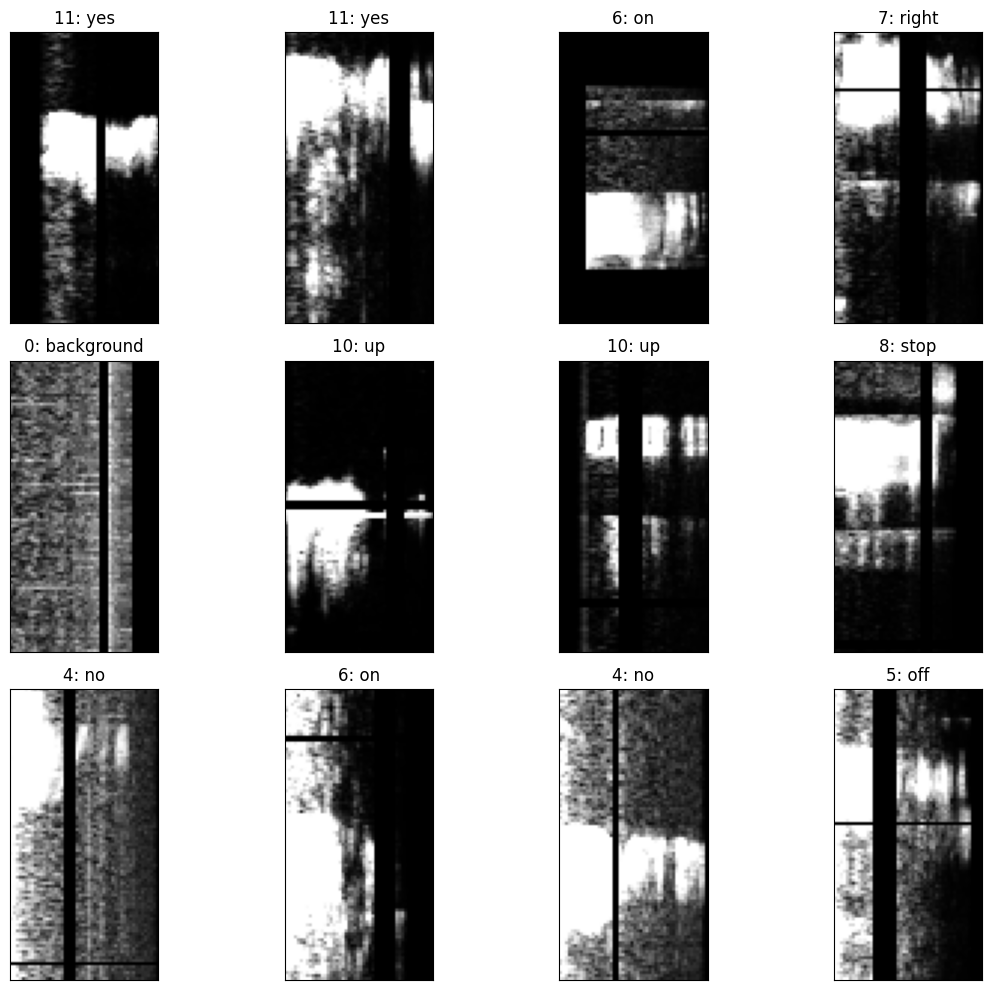

In [48]:
def visualize_images(trainloader, number_of_images=12):
    fig = plt.figure(figsize=(12,10))

    images, labels = next(iter(train_loader))

    num_rows = 3
    num_col = int(np.ceil(number_of_images/num_rows))

    for idx in range(min(number_of_images, len(images))):
        image, label = images[idx], labels[idx]

        #Create a subplot 
        ax = fig.add_subplot(num_rows, num_col, idx+1, xticks=[], yticks=[])

        image = image.squeeze()
        image = (image - image.min())/ (image.max() - image.min())
       
        ax.imshow(image, cmap='gray')

        ax.set_title(f"{label.item()}: {train_data.classes[label.item()]}")

    fig.tight_layout()

    plt.savefig("time_frequency_masking.pdf", dpi=600, bbox_inches="tight")
    plt.show()
visualize_images(train_loader)

#### CNN Model Implementation

In [15]:
class Model(nn.Module):
    def __init__(self, trial):
        super().__init__()

        self.base_num_filters = 32
        self.filter_size = 5 # Best parameter from the task 2
        self.num_layer = 5

        self.drop_out = trial.suggest_float("drop_out", 0.0, 0.7)

        layers = []

        width, height, c = 98, 50, 1

        filter_mul = 1

        for i in range(self.num_layer):
            layers.append(nn.Conv2d(in_channels=c, out_channels=self.base_num_filters * filter_mul, kernel_size=self.filter_size, padding="same"))
            layers.append(nn.BatchNorm2d(self.base_num_filters * filter_mul))
            layers.append(nn.ReLU())

            c = self.base_num_filters * filter_mul
            if ((i+1) % 2) == 0:
                layers.append(nn.MaxPool2d(kernel_size=(4,2), stride=(4,2)))
                filter_mul *= 2
                width = torch.floor_divide(width - 4, 4) + 1
                height = torch.floor_divide(height - 2, 2) + 1
                
        #-------Flatten------------
        layers.append(nn.Flatten())
        #------Classification------    
        layers.append(nn.Linear(in_features=width*height*c, out_features=256))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(p=self.drop_out))
        layers.append(nn.Linear(in_features=256, out_features=12))
        
        self._model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self._model(x)

In [16]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.base_num_filters = 32
        self.filter_size = 5 # Best parameter from the task 2
        self.num_layer = 5

        self.drop_out = 0.22117067990033082

        layers = []

        width, height, c = 98, 50, 1

        filter_mul = 1

        for i in range(self.num_layer):
            layers.append(nn.Conv2d(in_channels=c, out_channels=self.base_num_filters * filter_mul, kernel_size=self.filter_size, padding="same"))
            layers.append(nn.BatchNorm2d(self.base_num_filters * filter_mul))
            layers.append(nn.ReLU())

            c = self.base_num_filters * filter_mul
            if ((i+1) % 2) == 0:
                layers.append(nn.MaxPool2d(kernel_size=(4,2), stride=(4,2)))
                filter_mul *= 2
                width = torch.floor_divide(width - 4, 4) + 1
                height = torch.floor_divide(height - 2, 2) + 1
                
        #-------Flatten------------
        layers.append(nn.Flatten())
        #------Classification------    
        layers.append(nn.Linear(in_features=width*height*c, out_features=256))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(p=self.drop_out))
        layers.append(nn.Linear(in_features=256, out_features=12))
        
        self._model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self._model(x)

#### Model Training and Evaluation

In [17]:
def train(model, train_loader, optimizer, DEVICE):

    #set model to training mode
    model.train()

    #Move model to specified device
    model.to(DEVICE)

    running_loss = 0

    correct_prediction = 0

    total_samples = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        #Reset to zero
        optimizer.zero_grad()

        #Forward pass
        outputs = model(images)

        loss = F.cross_entropy(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, dim=1)

        total_samples += labels.size(0)

        correct_prediction += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)

    accuracy = 100 * correct_prediction/ total_samples

    return avg_loss, accuracy

In [18]:
def validation(model, val_loader, DEVICE):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)

            loss = F.cross_entropy(outputs, labels)

            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, dim=1)
            
            total_samples += labels.size(0)
            
            correct_predictions += (predicted == labels).sum().item()
            
        avg_loss = running_loss / len(val_loader)

        accuracy = 100 * correct_predictions/ total_samples

    return avg_loss, accuracy 

In [51]:
def reset_weights(m):
    if hasattr(m, "reset_parameters"):
        m.reset_parameters()

model = Model()

optimizer = torch.optim.Adam(model.parameters(), lr= train_config.learning_rate, weight_decay= 0.0004725992033945145) #best parameter

logdir = "runs/80epoch-3.3M_param_dropout"

writer = SummaryWriter(logdir)

dummy_input = (1,1,98,50)

print(summary(model, dummy_input, row_settings=["var_names"], device='cpu'))

model.apply(reset_weights)



Layer (type (var_name))                  Output Shape              Param #
Model (Model)                            [1, 12]                   --
├─Sequential (_model)                    [1, 12]                   --
│    └─Conv2d (0)                        [1, 32, 98, 50]           832
│    └─BatchNorm2d (1)                   [1, 32, 98, 50]           64
│    └─ReLU (2)                          [1, 32, 98, 50]           --
│    └─Conv2d (3)                        [1, 32, 98, 50]           25,632
│    └─BatchNorm2d (4)                   [1, 32, 98, 50]           64
│    └─ReLU (5)                          [1, 32, 98, 50]           --
│    └─MaxPool2d (6)                     [1, 32, 24, 25]           --
│    └─Conv2d (7)                        [1, 64, 24, 25]           51,264
│    └─BatchNorm2d (8)                   [1, 64, 24, 25]           128
│    └─ReLU (9)                          [1, 64, 24, 25]           --
│    └─Conv2d (10)                       [1, 64, 24, 25]           102,464


Model(
  (_model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=same)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=(4, 2), stride=(4, 2), padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=same)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=same)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=(4, 2), stride=(4, 2), padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), paddi

In [52]:
def main(model, trainloader, val_loader, DEVICE='cpu'):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_accuracy = 0.0
    best_weights = None

    for epoch in range(train_config.num_epochs):
        train_loss, train_accuracy = train(model,trainloader, optimizer, DEVICE)
        val_loss, val_accuracy = validation(model, val_loader, DEVICE)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1} - Train loss: {train_loss} Train accuracy: {train_accuracy} %%% Val loss: {val_loss} Val accuracy: {val_accuracy}")

        writer.add_scalar('Loss/train', train_loss)
        writer.add_scalar('Loss/val', val_loss)
        writer.add_scalar('Accuracy/train', train_accuracy)
        writer.add_scalar('Accuracy/val', val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_weights = model.state_dict()
            print("Saving the model... ")
            torch.save(best_weights, "best_task_6_param.pt")
            

    return train_losses, val_losses, train_accuracies, val_accuracies

In [53]:
train_losses, val_losses, train_accuracies, val_accuracies = main(model, train_loader, val_loader, 'cpu')

Validation: 100%|███████████████████████████████| 19/19 [00:07<00:00,  2.71it/s]


Epoch 1 - Train loss: 2.189378261566162 Train accuracy: 24.18790604697651 %%% Val loss: 2.4462826063758447 Val accuracy: 15.542271562766866
Saving the model... 


Validation: 100%|███████████████████████████████| 19/19 [00:06<00:00,  2.73it/s]


Epoch 2 - Train loss: 1.8871924839913845 Train accuracy: 37.08145927036482 %%% Val loss: 1.9666568464354466 Val accuracy: 33.21947053800171
Saving the model... 


Validation: 100%|███████████████████████████████| 19/19 [00:06<00:00,  2.80it/s]


...

Epoch 38 - Train loss: 0.20185805042274296 Train accuracy: 94.20289855072464 %%% Val loss: 1.2179947930731272 Val accuracy: 66.52433817250214


Validation: 100%|███████████████████████████████| 19/19 [00:06<00:00,  2.93it/s]


Epoch 39 - Train loss: 0.2204535489436239 Train accuracy: 93.80309845077461 %%% Val loss: 1.3199040970127833 Val accuracy: 66.69513236549957


Validation: 100%|███████████████████████████████| 19/19 [00:05<00:00,  3.37it/s]

Epoch 40 - Train loss: 0.21208487986586988 Train accuracy: 93.80309845077461 %%% Val loss: 1.2126336474167674 Val accuracy: 66.26814688300598


In [219]:
state_dict = torch.load("./best_task_6_param.pt")
model.load_state_dict(state_dict)

<All keys matched successfully>

In [54]:
def prediction(model, val_loader):

    model.eval()
    model.to(DEVICE)

    all_images, all_labels = [], []
    all_pred_indices, all_pred_probs = [], []

    for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with torch.inference_mode():
             outputs = model(images)

        prob = F.softmax(outputs,dim=1)
        pred_indices = prob.data.max(dim=1)[1]
        pred_probs = prob.data.max(dim=1)[0]

        all_images.append(images.cpu())
        all_labels.append(labels.cpu())
        all_pred_indices.append(pred_indices.cpu())
        all_pred_probs.append(pred_probs.cpu())


    return (torch.cat(all_images).numpy(),
            torch.cat(all_labels).numpy(),
            torch.cat(all_pred_indices).numpy(),
            torch.cat(all_pred_probs).numpy())

In [55]:
val_images, val_gt_labels, pred_indices, pred_probs = prediction(model, val_loader)

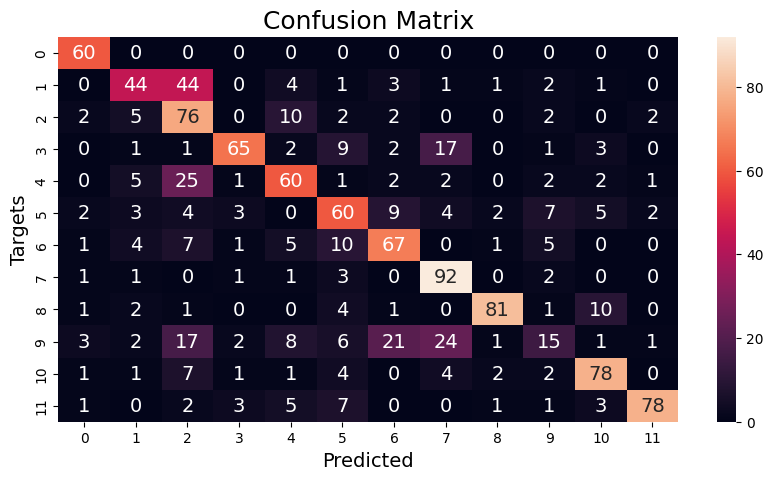

In [56]:
FONT_SIZE = 14
TITLE_SIZE = 18
X_LABEL_SIZE = 14
Y_LABEL_SIZE = 14
LEGEND_SIZE = 10

cm = confusion_matrix(y_true=val_gt_labels, y_pred = pred_indices)

plt.figure(figsize= [10,5])
sn.heatmap(cm, annot=True, fmt='d', annot_kws={"size":14})
plt.xlabel("Predicted", fontsize=X_LABEL_SIZE)
plt.ylabel("Targets", fontsize=Y_LABEL_SIZE)
plt.title(f"Confusion Matrix", fontsize=TITLE_SIZE)
plt.savefig("Confusion_Matrix_task4.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [57]:
model.eval()

Model(
  (_model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=same)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=(4, 2), stride=(4, 2), padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=same)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=same)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=(4, 2), stride=(4, 2), padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), paddi

In [58]:
for i, layer in enumerate(model._model):
    print(i, layer)

0 Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=same)
1 BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
2 ReLU()
3 Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=same)
4 BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
5 ReLU()
6 MaxPool2d(kernel_size=(4, 2), stride=(4, 2), padding=0, dilation=1, ceil_mode=False)
7 Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=same)
8 BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
9 ReLU()
10 Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=same)
11 BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
12 ReLU()
13 MaxPool2d(kernel_size=(4, 2), stride=(4, 2), padding=0, dilation=1, ceil_mode=False)
14 Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=same)
15 BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
16 ReLU()
17 Flatten(start_dim=1, end_dim=-

In [59]:
target_layer = model._model[14]  # adjust index

In [136]:
activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

In [104]:
val_iter = iter(val_loader)
data, label = next(val_iter)
data, label = next(val_iter)  # batch 2
data, label = next(val_iter)  # batch 3
data, label = next(val_iter)  # batch 3
data, label = next(val_iter)  # batch 3
data, label = next(val_iter)  # batch 3
print(label)

tensor([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])


torch.Size([1, 1, 98, 50]) no


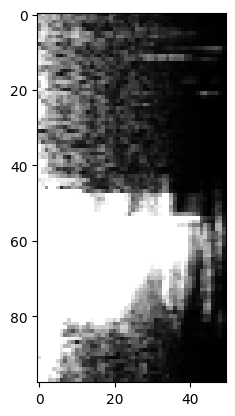

In [137]:
i = 63
input_tensor = data[i]
image = input_tensor.squeeze()
image = (image - image.min())/ (image.max() - image.min())       
plt.imshow(image, cmap='gray')
input_tensor = input_tensor.unsqueeze(1)
print(input_tensor.shape, train_data.classes[label[i]])

In [138]:
model.eval()

output = model(input_tensor)  # shape [1, 12]

pred_class = output.argmax(dim=1)

print(pred_class)

tensor([2])


In [139]:
model.zero_grad()
output[0, pred_class].backward()

In [140]:
acts = activations[0].squeeze(0)   # [C, H, W]
grads = gradients[0].squeeze(0)    # [C, H, W]

weights = grads.mean(dim=(1, 2))   # [C]

cam = torch.zeros(acts.shape[1:], dtype=torch.float32)

for i in range(len(weights)):
    cam += weights[i] * acts[i]

cam = torch.relu(cam)

# normalize
cam -= cam.min()
cam /= cam.max()

In [35]:
import cv2

In [141]:
cam = cam.detach().numpy()

cam = cv2.resize(cam, (98, 50))  # your input size

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)

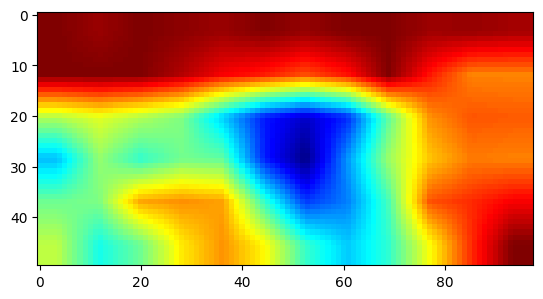

In [142]:
plt.imshow(heatmap)

In [76]:
heatmap[80][0]

IndexError: index 80 is out of bounds for axis 0 with size 50

In [143]:
heatmap = cv2.rotate(heatmap, cv2.ROTATE_90_CLOCKWISE)

In [144]:
img = input_tensor.squeeze().detach().cpu().numpy()

# normalize to 0–1 for display
img = img - img.min()
img = img / img.max()

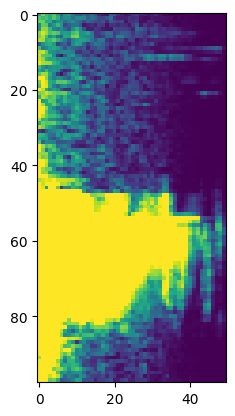

In [145]:
img = np.uint8(255 * img)
plt.imshow(img)

In [146]:
img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
overlay = cv2.addWeighted(img, 0.5, heatmap, 0.5, 0)

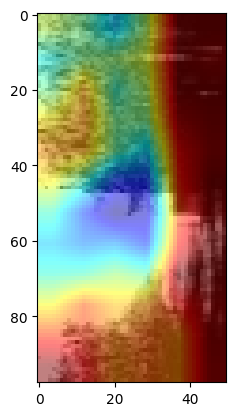

In [147]:
plt.imshow(overlay)

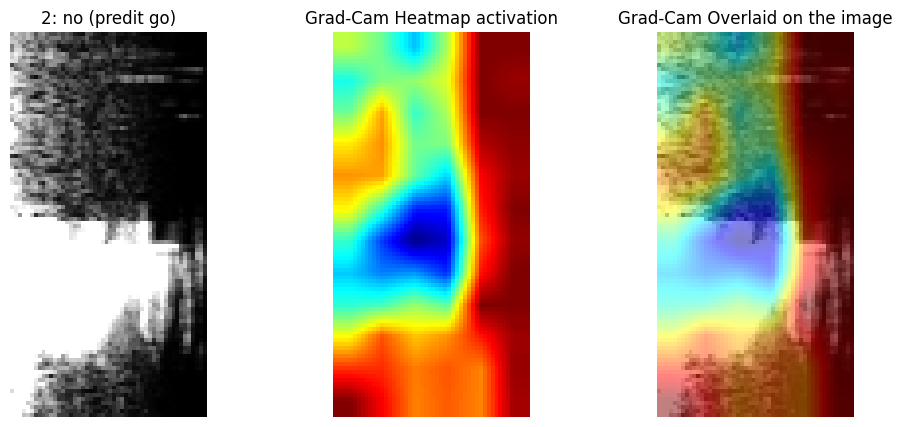

In [148]:
PLOT_FILE = "task_5_grad_cam_no_after_translation_failure.pdf"

plt.figure(figsize=[16,5])

plt.subplot(141)
plt.imshow(img)
plt.axis('off')
plt.title("2: no (predit go)")

plt.subplot(142)
plt.imshow(heatmap)
plt.axis('off')
plt.title("Grad-Cam Heatmap activation")

plt.subplot(143)
plt.imshow(overlay)
plt.axis('off')
plt.title("Grad-Cam Overlaid on the image")

plt.savefig(PLOT_FILE, dpi=600, bbox_inches="tight")